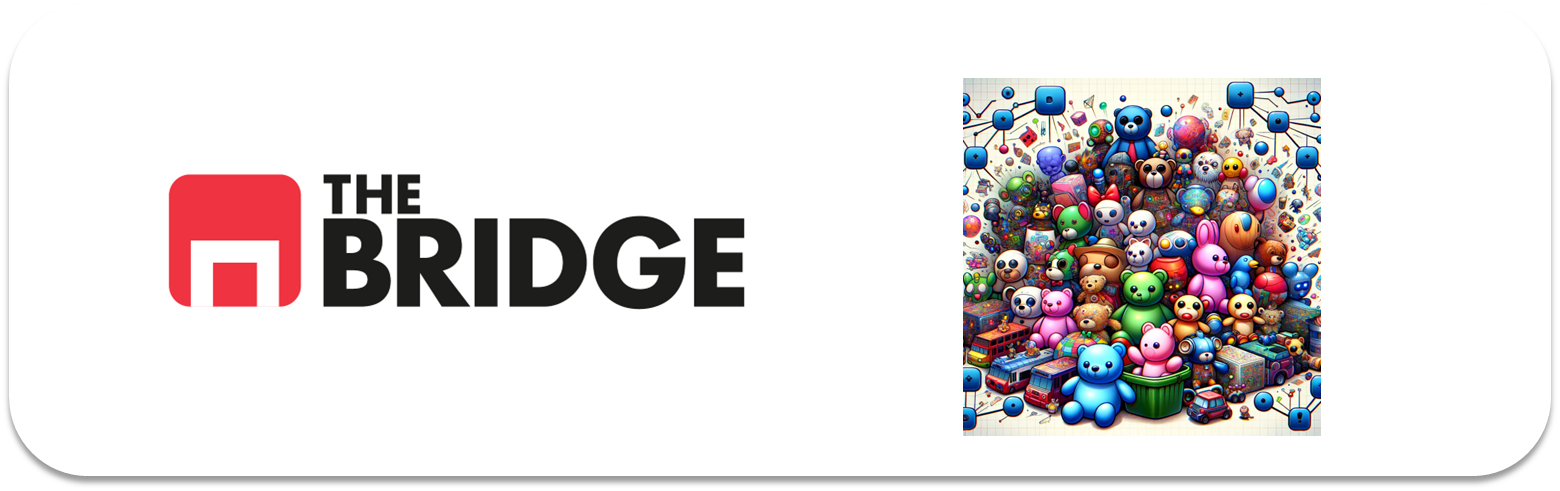

## PRACTICA OBLIGATORIA: **K-Means Clustering**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado sobre imágenes para practicar con el algoritmo k-means. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier

## **#1**

Vamos a trabajar con un dataset también entre los "clásicos" (aunque a veces menos conocido) que es el de rostros Olivetti. Este dataset contiene 400 imágenes en escala de grises de 64 × 64 píxeles de rostros.   


Como en otros datasets de imágenes, estás están "aplanadas" de forma que cada pixel es una feature y por cada imagen hay $64\times 64 = 4096$ features.  

Se fotografiaron 40 personas diferentes (10 veces cada una) y esas fotografías se recogen en el dataset.  

La tarea habitual es entrenar un modelo que pueda predecir qué persona está representada en cada imagen, pero nosotros lo vamos a hacer de forma no supervisada. 



### #1.1


Carga el conjunto de datos usando la función `sklearn.datasets.fetch_olivetti_faces()`. Recuerda que se carga un "diccionario". Muestra su descripción acudiendo a la clave "DESCR".

In [ ]:
olivetti = fetch_olivetti_faces()
print(olivetti.DESCR)

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

### #1.2 

Aunque no lo vas a usar hasta el final de la práctica, muestra el target. Luego cargalo todo en un mismo dataframe (tendrás que añadir el target) y obtén otro dataset con todas las imagenes reordenadas aleatoriamente (emplea por ejemplo el método `sample` del dataframe o el método que tú quieras)

In [ ]:
# Target: un número del 0 al 39 que identifica a cada persona
print("Target:", olivetti.target)

# Construimos el dataframe con todas las features (4096 píxeles) más la columna de target
df_faces = pd.DataFrame(olivetti.data, columns=[f"px_{i}" for i in range(4096)])
df_faces["target"] = olivetti.target

# El dataset viene ordenado por persona, así que lo mezclamos
df_faces = df_faces.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\nDataframe mezclado: {df_faces.shape}")
df_faces.head()

Target: [ 0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  2  2  2  2
  2  2  2  2  2  2  3  3  3  3  3  3  3  3  3  3  4  4  4  4  4  4  4  4
  4  4  5  5  5  5  5  5  5  5  5  5  6  6  6  6  6  6  6  6  6  6  7  7
  7  7  7  7  7  7  7  7  8  8  8  8  8  8  8  8  8  8  9  9  9  9  9  9
  9  9  9  9 10 10 10 10 10 10 10 10 10 10 11 11 11 11 11 11 11 11 11 11
 12 12 12 12 12 12 12 12 12 12 13 13 13 13 13 13 13 13 13 13 14 14 14 14
 14 14 14 14 14 14 15 15 15 15 15 15 15 15 15 15 16 16 16 16 16 16 16 16
 16 16 17 17 17 17 17 17 17 17 17 17 18 18 18 18 18 18 18 18 18 18 19 19
 19 19 19 19 19 19 19 19 20 20 20 20 20 20 20 20 20 20 21 21 21 21 21 21
 21 21 21 21 22 22 22 22 22 22 22 22 22 22 23 23 23 23 23 23 23 23 23 23
 24 24 24 24 24 24 24 24 24 24 25 25 25 25 25 25 25 25 25 25 26 26 26 26
 26 26 26 26 26 26 27 27 27 27 27 27 27 27 27 27 28 28 28 28 28 28 28 28
 28 28 29 29 29 29 29 29 29 29 29 29 30 30 30 30 30 30 30 30 30 30 31 31
 31 31 31 31 31 31 31 31 32 32 32 32 32 32 

,px_0,px_1,px_2,px_3,px_4,px_5,px_6,px_7,px_8,px_9,...,px_4087,px_4088,px_4089,px_4090,px_4091,px_4092,px_4093,px_4094,px_4095,target
0,0.198347,0.235537,0.351240,0.409091,0.421488,0.429752,0.500000,0.528926,0.524793,0.553719,...,0.508264,0.524793,0.504132,0.483471,0.471074,0.285124,0.061983,0.128099,0.090909,20
1,0.185950,0.128099,0.115702,0.132231,0.185950,0.268595,0.433884,0.541322,0.570248,0.586777,...,0.396694,0.409091,0.301653,0.421488,0.462810,0.247934,0.190083,0.210744,0.210744,28
2,0.508264,0.603306,0.619835,0.628099,0.657025,0.665289,0.690083,0.727273,0.743802,0.768595,...,0.301653,0.305785,0.314050,0.326446,0.338843,0.330579,0.334711,0.342975,0.342975,3
3,0.136364,0.140496,0.185950,0.280992,0.318182,0.363636,0.409091,0.417355,0.438017,0.454545,...,0.169421,0.206612,0.276859,0.355372,0.685950,0.661157,0.280992,0.371901,0.276859,21
4,0.652893,0.644628,0.652893,0.706612,0.714876,0.719008,0.743802,0.747934,0.747934,0.756198,...,0.074380,0.074380,0.082645,0.082645,0.111570,0.070248,0.086777,0.185950,0.231405,9


### #1.3

Vamos a dividir en train y test, pero OJO RECUERDA QUE EN LOS PROBLEMAS NO SUPERVISADOS NO HAY SPLIT (porque no hay target), aquí lo hacemos para poder comparar posteriormente el clustering con la clasificación (ya que es uan práctica formativa).

Por tanto, divídelo en un conjunto de entrenamiento, un conjunto de validación y un conjunto de pruebas (80-10-10). Dado que el conjunto de datos es bastante pequeño, emplea un muestreo estratificado para asegurarse de que haya el mismo número de imágenes por persona en cada conjunto (estratificando por la columna que contenga el target)

NOTA: No hemos hecho hasta ahora la separación en tres sets, investiga por tu cuenta o bien haz primero un split 90-10 y luego otro split 89-11 sobre el de 80 (para que de los números aproximados), por ejemplo.

In [ ]:
# Separamos primero el 20% (valid + test), luego lo dividimos al 50/50
# Usamos estratificación para que cada persona tenga representación en los tres sets
train_set, tmp_set = train_test_split(
    df_faces, test_size=0.2, stratify=df_faces["target"], random_state=42
)
valid_set, test_set = train_test_split(
    tmp_set, test_size=0.5, stratify=tmp_set["target"], random_state=42
)

print(f"Train: {len(train_set)} | Validación: {len(valid_set)} | Test: {len(test_set)}")

Train: 320 | Validación: 40 | Test: 40


### #1.4

Crea los pares X,y para train, validation y test.

In [ ]:
X_train = train_set.drop("target", axis=1)
X_valid = valid_set.drop("target", axis=1)
X_test  = test_set.drop("target", axis=1)

y_train = train_set["target"]
y_valid = valid_set["target"]
y_test  = test_set["target"]

print(f"X_train: {X_train.shape}, X_valid: {X_valid.shape}, X_test: {X_test.shape}")

X_train: (320, 4096), X_valid: (40, 4096), X_test: (40, 4096)


Utiliza la siguiente función para visualizar alguna de las caras (observa que tienes que dar la X y la y, usa iloc en ambos datasets)

In [ ]:
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

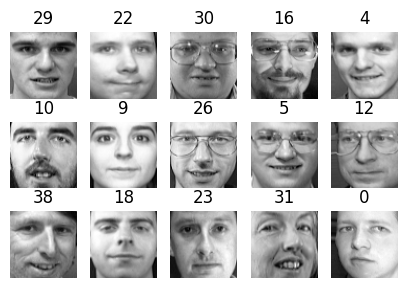

In [ ]:
# Pintamos las primeras 15 imágenes del set de validación para hacernos una idea
plot_faces(X_valid.iloc[:15].values, y_valid.iloc[:15].values)

### #1.5

Para acelerar las cosas, reduciremos la dimensionalidad de los datos utilizando PCA (técnica que veremos en el siguiente sprint). Modifica la siguiente celda de forma que las X se correspondan con las que has utilizado en el ejercicio anterior.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(0.99)
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca = pca.transform(X_test)

pca.n_components_

np.int64(221)

### 1.6

Aquí viene la parte del león. A continuación, agrupa las imágenes utilizando K-Means sobre el dataset de train reducido en el ejercicio anterior. Emplea el método del máximo de score de silueta para obtener el mejor k, probando con K de 5 en 5 hasta 150. ¿Cuál es el k que proporciona el mejor score de silueta? NOTA: Emplea todas las features (no hace falta seleccionar, y ya están escaladas entre 0 y 1)

k=  5  silhouette=0.1069
k= 10  silhouette=0.0918
k= 15  silhouette=0.0969
k= 20  silhouette=0.1089
k= 25  silhouette=0.1189
k= 30  silhouette=0.1302
k= 35  silhouette=0.1406
k= 40  silhouette=0.1508
k= 45  silhouette=0.1597
k= 50  silhouette=0.1710
k= 55  silhouette=0.1687
k= 60  silhouette=0.1802
k= 65  silhouette=0.1804
k= 70  silhouette=0.1882
k= 75  silhouette=0.1966
k= 80  silhouette=0.1973
k= 85  silhouette=0.1887
k= 90  silhouette=0.1985
k= 95  silhouette=0.2014
k=100  silhouette=0.2017
k=105  silhouette=0.2027
k=110  silhouette=0.2031
k=115  silhouette=0.2061
k=120  silhouette=0.2088
k=125  silhouette=0.2082
k=130  silhouette=0.2054
k=135  silhouette=0.2057
k=140  silhouette=0.1992
k=145  silhouette=0.2037
k=150  silhouette=0.1983

Mejor k (silueta): 120  |  score: 0.2088


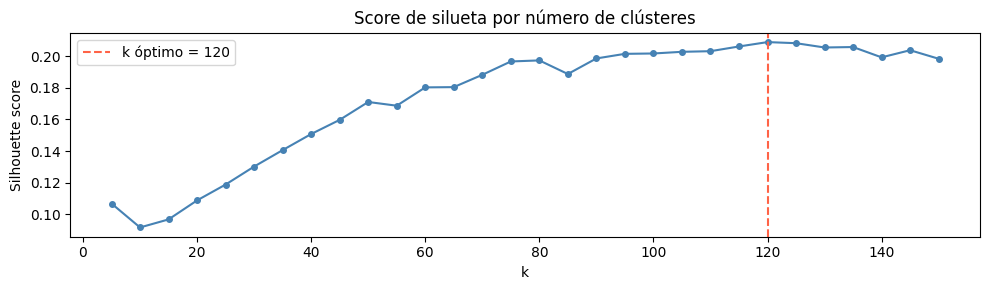

In [ ]:
k_range = list(range(5, 151, 5))
kmeans_list = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_train_pca)
    kmeans_list.append(km)
    score = silhouette_score(X_train_pca, km.labels_)
    sil_scores.append(score)
    print(f"k={k:3d}  silhouette={score:.4f}")

best_idx = int(np.argmax(sil_scores))
best_k   = k_range[best_idx]
print(f"\nMejor k (silueta): {best_k}  |  score: {sil_scores[best_idx]:.4f}")

plt.figure(figsize=(10, 3))
plt.plot(k_range, sil_scores, "o-", color="steelblue", markersize=4)
plt.axvline(best_k, color="tomato", linestyle="--", label=f"k óptimo = {best_k}")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Score de silueta por número de clústeres")
plt.legend()
plt.tight_layout()
plt.show()

### #1.7

Repite el ejercio anterior empleando ahora el método del codo de Inercia. ¿Sale algo más concluyente o que refuerce el anterior resultado?

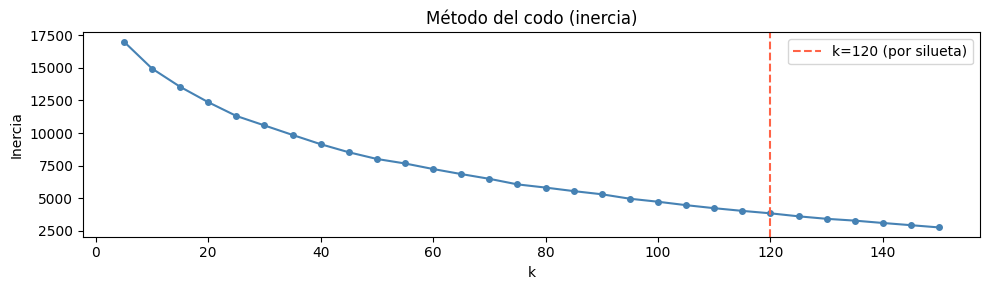

In [ ]:
inertias = [km.inertia_ for km in kmeans_list]

plt.figure(figsize=(10, 3))
plt.plot(k_range, inertias, "o-", color="steelblue", markersize=4)
plt.axvline(best_k, color="tomato", linestyle="--", label=f"k={best_k} (por silueta)")
plt.xlabel("k")
plt.ylabel("Inercia")
plt.title("Método del codo (inercia)")
plt.legend()
plt.tight_layout()
plt.show()

La curva de inercia no muestra un codo nítido: baja de forma más o menos suave en todo el rango. No contradice al criterio de silueta pero tampoco sirve para confirmar un k concreto. Que no haya codo claro tiene sentido aquí: el dataset tiene solo 400 imágenes y 40 personas, y cada persona aparece con poses y expresiones bastante distintas, por lo que el espacio no se organiza en pocos grupos compactos. Me quedo con k obtenido por silueta.

### #1.8

Quédate con el k obtenido con el método del score de silueta y asigna el modelo con ese k a una variable `best_model`

In [ ]:
best_model = kmeans_list[best_idx]
print(f"best_model -> KMeans con k={best_model.n_clusters}")

best_model -> KMeans con k=120


### #1.9

Haz una valoración del método de clustering para el K elegido. Para ello crea un programa que recorra la lista de etiquetas dadas por "best_model" y que, haciendo uso de la función que ya te hemos proporcionado, pinte las caras asignadas a los 10 primeros clústeres. Ojo tendrás que hacer una pequeña adaptación porque las features de entrenamiento no son las features reales (son una "transformación" de estas) y si pasas el X de entrenamiento no verás nada. ¿Ves caras similares?


--- Clúster 0  (3 imágenes) ---


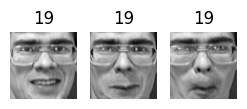


--- Clúster 1  (4 imágenes) ---


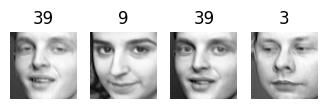


--- Clúster 2  (6 imágenes) ---


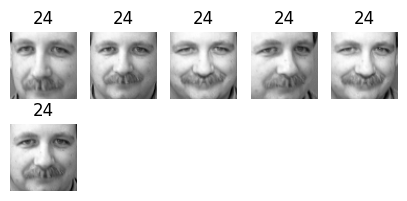


--- Clúster 3  (5 imágenes) ---


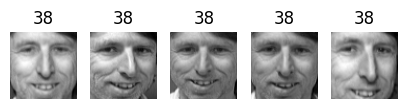


--- Clúster 4  (2 imágenes) ---


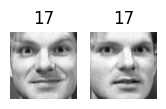


--- Clúster 5  (3 imágenes) ---


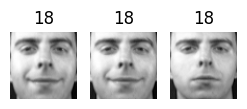


--- Clúster 6  (4 imágenes) ---


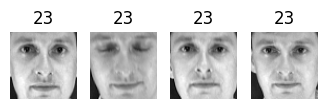


--- Clúster 7  (7 imágenes) ---


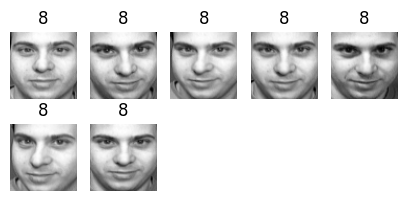


--- Clúster 8  (4 imágenes) ---


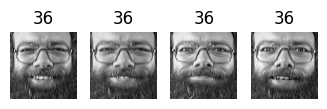


--- Clúster 9  (4 imágenes) ---


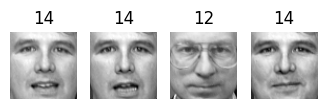


--- Clúster 10  (3 imágenes) ---


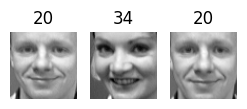


--- Clúster 11  (4 imágenes) ---


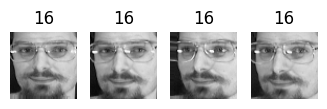


--- Clúster 12  (1 imágenes) ---


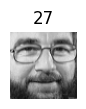


--- Clúster 13  (5 imágenes) ---


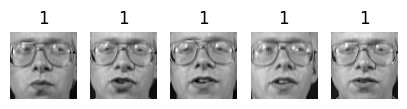


--- Clúster 14  (3 imágenes) ---


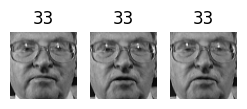


--- Clúster 15  (4 imágenes) ---


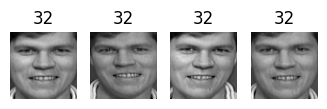


--- Clúster 16  (2 imágenes) ---


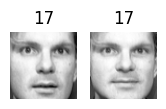


--- Clúster 17  (7 imágenes) ---


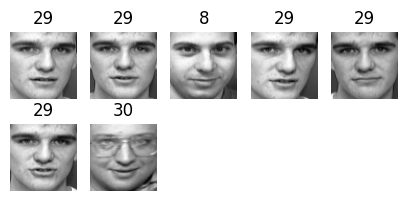


--- Clúster 18  (3 imágenes) ---


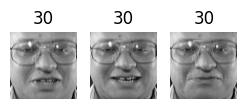


--- Clúster 19  (7 imágenes) ---


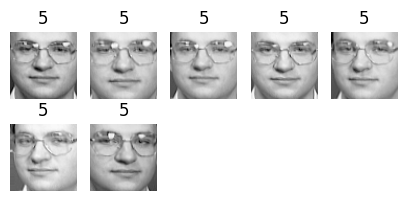

In [ ]:
# X_train_pca no sirve para visualizar (no tiene 64x64), así que pintamos
# las imágenes originales filtrando con las etiquetas que da best_model.
unique_labels = np.unique(best_model.labels_)
n_clusters_a_mostrar = 20

for cluster_id in unique_labels[:n_clusters_a_mostrar]:
    mask = best_model.labels_ == cluster_id
    faces_cluster  = X_train[mask].values
    labels_cluster = y_train[mask]
    print(f"\n--- Clúster {cluster_id}  ({mask.sum()} imágenes) ---")
    plot_faces(faces_cluster, labels_cluster)

Mirando los clústeres, bastantes de ellos sí agrupan caras que parecen de la misma persona, aunque no todos. Hay varios clústeres con una sola imagen y otros en los que se cuela alguien que no pega con el resto. Con 40 personas reales y k=120, es lógico que cada persona se reparta entre varios clústeres y que algunos queden mezclados. Como método de agrupación no es perfecto, pero como apoyo para etiquetar rápido un dataset nuevo podría ser útil.

## **#2**


### #2.1


Continuando con el conjunto de datos de caras Olivetti, entrena un clasificador para predecir qué persona está representada en cada imagen, y evalúalo en el conjunto de validación. Utiliza un RandomForest con 150 submodelos o estimadores (y el resto de hiperparámetros déjalos a su valor por defecto)

In [ ]:
# RF sobre las features reducidas por PCA (~221 features)
rf_pca = RandomForestClassifier(n_estimators=150, random_state=42)
rf_pca.fit(X_train_pca, y_train)
acc_pca = rf_pca.score(X_valid_pca, y_valid)

# RF sobre las 4096 features originales, para tener referencia
rf_full = RandomForestClassifier(n_estimators=150, random_state=42)
rf_full.fit(X_train, y_train)
acc_full = rf_full.score(X_valid, y_valid)

print(f"RF sobre PCA  ({X_train_pca.shape[1]} features)   -> accuracy valid: {acc_pca:.4f}")
print(f"RF sobre X original (4096 features) -> accuracy valid: {acc_full:.4f}")

RF sobre PCA  (221 features)   -> accuracy valid: 0.9250
RF sobre X original (4096 features) -> accuracy valid: 0.9250


### #2.2

Utiliza K-Means como una herramienta de reducción de dimensionalidad y entrena un clasificador en el conjunto reducido. Para ello emplea el método transform de manera que ahora las features de entrada sean las distancias de cada punto a los centroides del modelo "best_model" de la parte anterior. Por ejemplo:
```python
X_train_reduced = best_model.transform(X_train_pca) 
```


Ojo lo tienes que aplicar a todos los datasets. Luego vuelve a entrenar un RandomForest sobre este dataset y evalualo contra el dataset de validacion.

In [ ]:
# Nuevas features: distancia de cada muestra a los k centroides de best_model
X_train_dist = best_model.transform(X_train_pca)
X_valid_dist = best_model.transform(X_valid_pca)
X_test_dist  = best_model.transform(X_test_pca)

print(f"Forma de las nuevas features (distancias): {X_train_dist.shape}")

rf_dist = RandomForestClassifier(n_estimators=150, random_state=42)
rf_dist.fit(X_train_dist, y_train)
acc_dist = rf_dist.score(X_valid_dist, y_valid)

print("\nResumen en validación:")
print(f"  RF sobre PCA           ({X_train_pca.shape[1]:>4} features) -> {acc_pca:.4f}")
print(f"  RF sobre X original    (4096 features) -> {acc_full:.4f}")
print(f"  RF sobre KMeans-transf ({X_train_dist.shape[1]:>4} features) -> {acc_dist:.4f}")

Forma de las nuevas features (distancias): (320, 120)

Resumen en validación:
  RF sobre PCA           ( 221 features) -> 0.9250
  RF sobre X original    (4096 features) -> 0.9250
  RF sobre KMeans-transf ( 120 features) -> 0.8000


Pasar las features a distancias a centroides no mejora al baseline de PCA y además queda por debajo del RF sobre las 4096 features originales. Tiene sentido: el clustering no está separando bien a las 40 personas (lo vimos en #1.9), así que las distancias a esos centroides tampoco son una representación muy informativa para clasificar. En este caso PCA por sí solo ya resume bien la imagen con muchas menos features.

### #2.3 EXTRA VOLUNTARIO

Busca el número de clusters k que generen un algoritmo kmeans que a su vez sus distancias a los centroides sean las features de un clasificador RandomForest y que permita al clasificador obtener el mejor rendimiento: ¿Qué rendimiento puedes alcanzar? (en terminos de Accuracy)

k=  5  accuracy valid=0.3750
k= 10  accuracy valid=0.5750
k= 15  accuracy valid=0.6750
k= 20  accuracy valid=0.6750
k= 25  accuracy valid=0.7000
k= 30  accuracy valid=0.7000
k= 35  accuracy valid=0.7750
k= 40  accuracy valid=0.8250
k= 45  accuracy valid=0.8000
k= 50  accuracy valid=0.8000
k= 55  accuracy valid=0.7500
k= 60  accuracy valid=0.7500
k= 65  accuracy valid=0.8000
k= 70  accuracy valid=0.7500
k= 75  accuracy valid=0.8000
k= 80  accuracy valid=0.7750
k= 85  accuracy valid=0.8000
k= 90  accuracy valid=0.8000
k= 95  accuracy valid=0.8000
k=100  accuracy valid=0.7500
k=105  accuracy valid=0.7500
k=110  accuracy valid=0.7750
k=115  accuracy valid=0.7750
k=120  accuracy valid=0.8000
k=125  accuracy valid=0.7750
k=130  accuracy valid=0.7500
k=135  accuracy valid=0.8000
k=140  accuracy valid=0.7750
k=145  accuracy valid=0.7750
k=150  accuracy valid=0.7750

Mejor k para RF: 40  |  accuracy: 0.8250


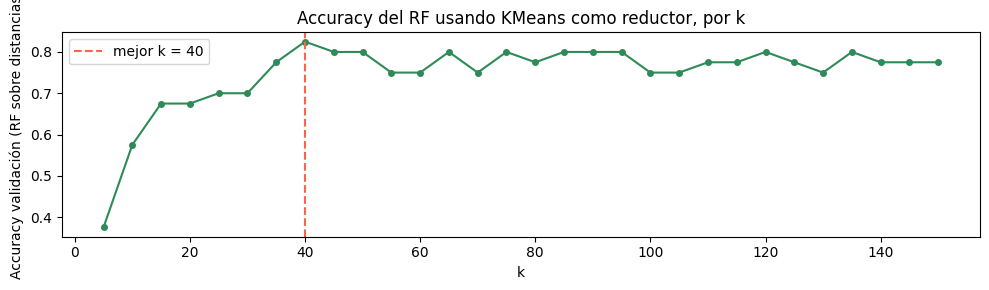

In [ ]:
# Reutilizo los modelos ya entrenados en kmeans_list (uno por cada k del #1.6),
# así evito volver a ajustar KMeans. Para cada k, construyo las features de
# distancia con .transform y evalúo un RF en validación.

rf_accs = []
for km, k in zip(kmeans_list, k_range):
    X_tr  = km.transform(X_train_pca)
    X_val = km.transform(X_valid_pca)
    rf = RandomForestClassifier(n_estimators=150, random_state=42)
    rf.fit(X_tr, y_train)
    acc = rf.score(X_val, y_valid)
    rf_accs.append(acc)
    print(f"k={k:3d}  accuracy valid={acc:.4f}")

best_k_rf = k_range[int(np.argmax(rf_accs))]
best_acc_rf = max(rf_accs)
print(f"\nMejor k para RF: {best_k_rf}  |  accuracy: {best_acc_rf:.4f}")

plt.figure(figsize=(10, 3))
plt.plot(k_range, rf_accs, "o-", color="seagreen", markersize=4)
plt.axvline(best_k_rf, color="tomato", linestyle="--", label=f"mejor k = {best_k_rf}")
plt.xlabel("k")
plt.ylabel("Accuracy validación (RF sobre distancias)")
plt.title("Accuracy del RF usando KMeans como reductor, por k")
plt.legend()
plt.tight_layout()
plt.show()

El mejor k para clasificar con RF no coincide con el que da mejor silueta, lo cual es razonable: el criterio de silueta mide cómo de compactos y separados están los clústeres, no cómo de útiles son para una tarea supervisada. Aun así, incluso el mejor resultado con KMeans-transform se queda por debajo del RF sobre PCA y del RF sobre las 4096 features originales, así que en este dataset el clustering no aporta como reductor para la clasificación.